# 📉 Customer Churn Prediction — Full ML Pipeline
**Dataset:** IBM Telco Customer Churn (loaded via URL)  
**Imbalance Handling:** SMOTE vs Class Weights — both compared  
**Models:** Logistic Regression · Random Forest · XGBoost · LightGBM  
**Explainability:** SHAP (beeswarm, bar, force) + Feature Importance  

---

## 📦 Step 1 — Install & Import Libraries

In [1]:
!pip install xgboost lightgbm shap imbalanced-learn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline

# imbalanced-learn
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

print('✅ All libraries loaded!')

✅ All libraries loaded!


## 📥 Step 2 — Load Dataset

In [3]:
# IBM Telco Customer Churn — loaded directly from GitHub (no upload needed)
# 7043 customers, 21 features, binary target: Churn (Yes/No)
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)

print('Dataset Shape:', df.shape)
print('\nColumn names:')
print(list(df.columns))
df.head()

Dataset Shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🔍 Step 3 — Exploratory Data Analysis (EDA)

In [4]:
# ── Basic info ──
print('Data Types & Non-Null Counts:')
print(df.info())

Data Types & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBil

Churn Distribution:
  No: 5174 samples (73.5%)
  Yes: 1869 samples (26.5%)


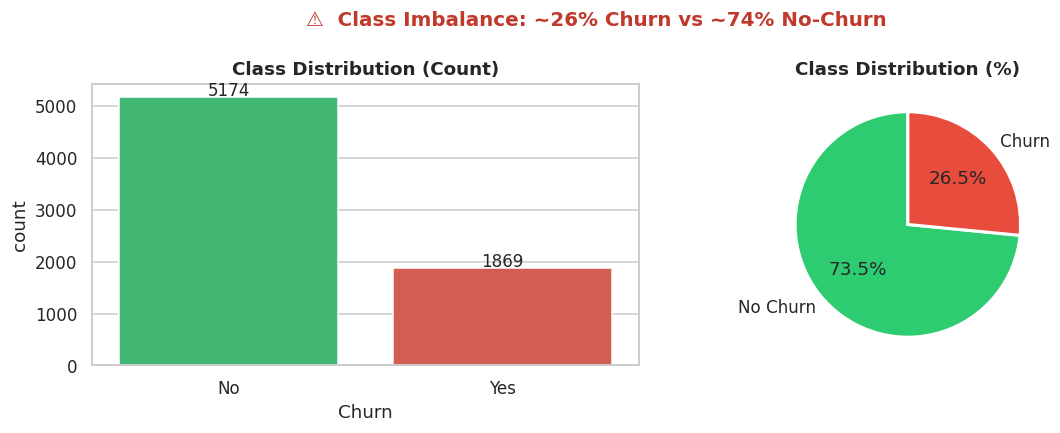

In [5]:
# ── Target class distribution ──
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Churn Distribution:')
for label in churn_counts.index:
    print(f'  {label}: {churn_counts[label]} samples ({churn_pct[label]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count bar
sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'], ax=axes[0])
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 30),
                     ha='center', fontsize=11)

# Pie chart
axes[1].pie(churn_counts, labels=['No Churn','Churn'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Distribution (%)', fontweight='bold')

plt.suptitle('⚠️  Class Imbalance: ~26% Churn vs ~74% No-Churn',
             fontsize=13, fontweight='bold', color='#c0392b')
plt.tight_layout()
plt.show()

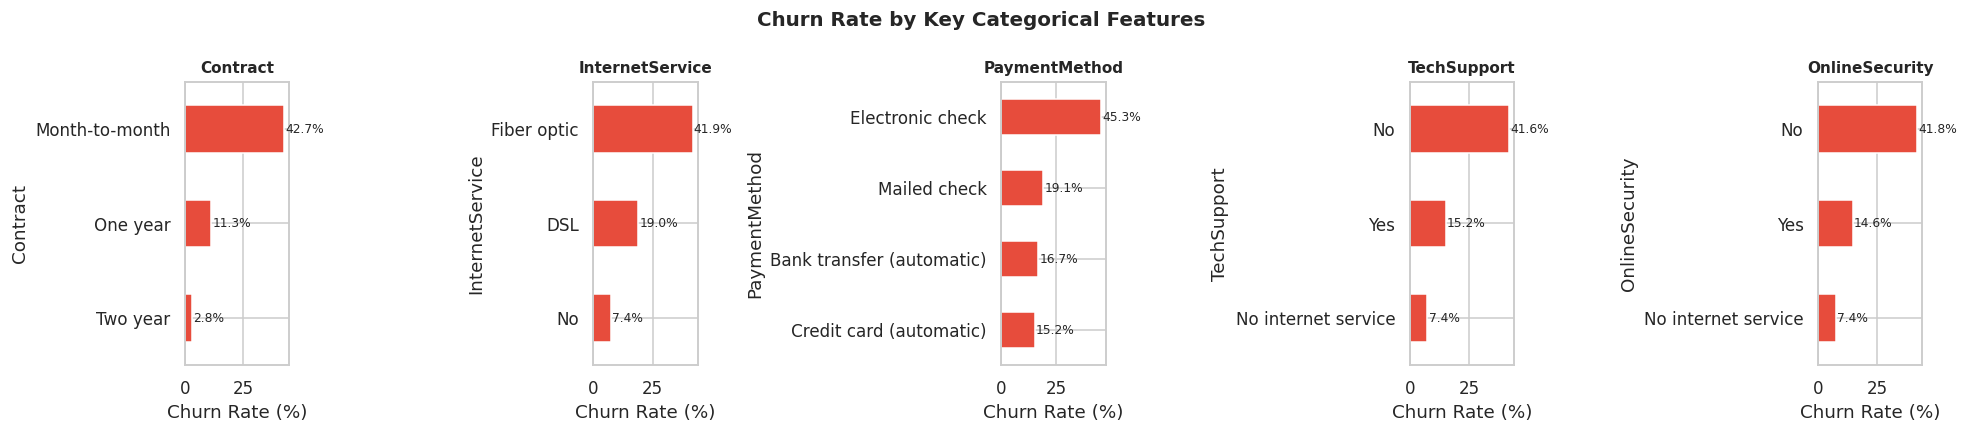

In [6]:
# ── Churn rate by key categorical features ──
cat_cols = ['Contract','InternetService','PaymentMethod','TechSupport','OnlineSecurity']
fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 4))

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('Churn Rate (%)')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%',
                    (p.get_width() + 0.5, p.get_y() + p.get_height()/2),
                    va='center', fontsize=8)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

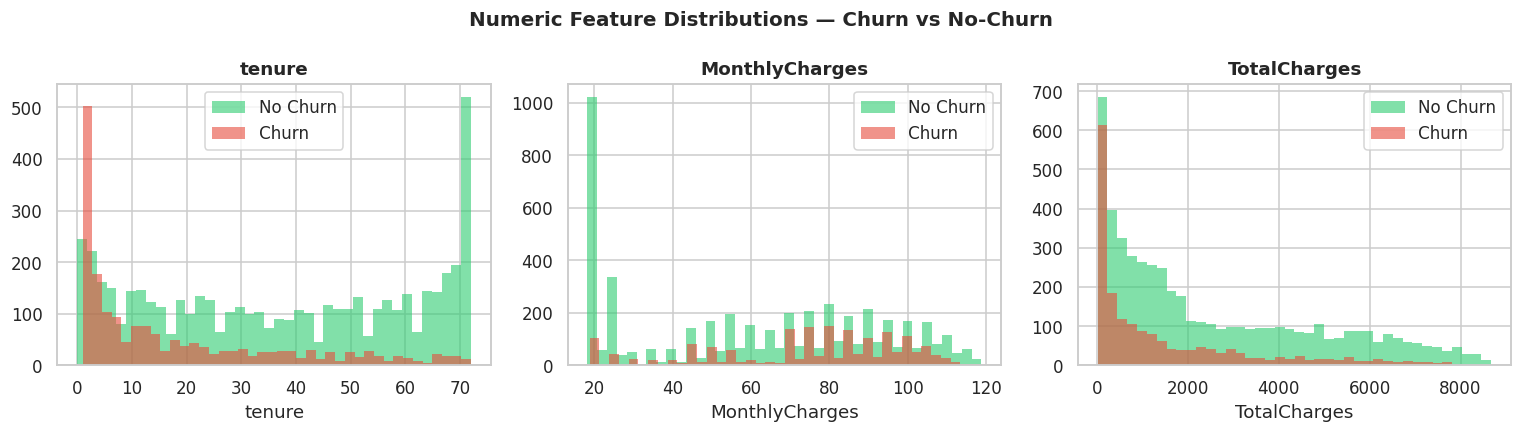

In [7]:
# ── Numeric feature distributions by churn ──
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, num_cols):
    df_plot = df.copy()
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
    for churn_val, color, label in [('No','#2ecc71','No Churn'),('Yes','#e74c3c','Churn')]:
        subset = df_plot[df_plot['Churn']==churn_val][col].dropna()
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.legend()

plt.suptitle('Numeric Feature Distributions — Churn vs No-Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🛠️ Step 4 — Preprocessing

In [8]:
# ── Step 4a: Drop customerID (unique identifier, no predictive value) ──
df = df.drop('customerID', axis=1)

# ── Step 4b: Fix TotalCharges — stored as string, convert to numeric ──
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Missing values after conversion:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill TotalCharges NaN with median (only 11 missing — safe to impute)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
print('\nMissing values after imputation:', df.isnull().sum().sum(), '✅')

Missing values after conversion:
TotalCharges    11
dtype: int64

Missing values after imputation: 0 ✅


In [9]:
# ── Step 4c: Encode binary columns (Yes/No → 1/0) ──
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# SeniorCitizen already 0/1

# ── Step 4d: One-Hot Encode multi-class categorical columns ──
multi_cat = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
             'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
             'Contract','PaymentMethod']
df = pd.get_dummies(df, columns=multi_cat, drop_first=True)  # drop_first avoids dummy trap

# Convert all bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('Shape after encoding:', df.shape)
print('All dtypes numeric:', (df.dtypes != 'object').all())

Shape after encoding: (7043, 31)
All dtypes numeric: False


In [10]:
# ── Step 4e: Feature Engineering ──

# Monthly charge per tenure month (cost rate)
df['ChargePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Has any add-on service (streaming, backup, security)
service_cols = [c for c in df.columns if 'Streaming' in c or 'Backup' in c or 'Security' in c]
df['NumServices'] = df[service_cols].sum(axis=1)

print('Engineered features: ChargePerMonth, NumServices')
print('Final dataset shape:', df.shape)

Engineered features: ChargePerMonth, NumServices
Final dataset shape: (7043, 33)


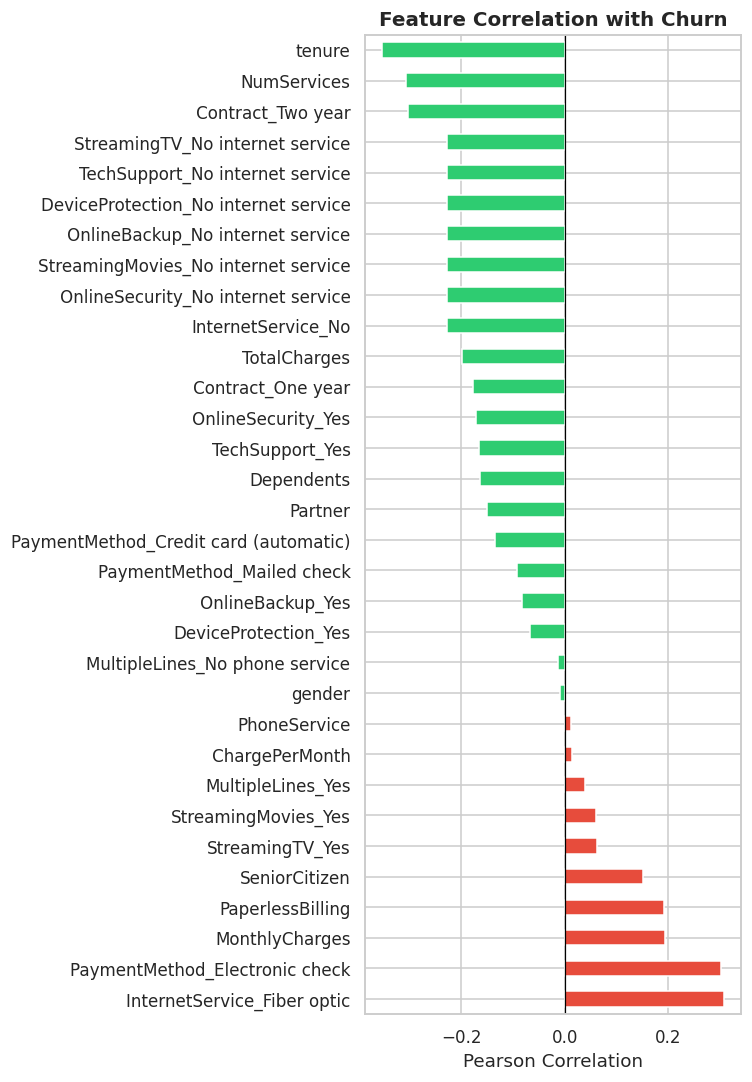

In [12]:
df['gender'] = df['gender'].map({'Female': 0, 'Male': 1})

# ── Correlation with target ──
corr_churn = df.corr()['Churn'].drop('Churn').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 10))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_churn]
corr_churn.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

## ✂️ Step 5 — Train/Test Split

In [13]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Stratified split — preserves churn ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test  churn rate: {y_test.mean()*100:.1f}%')

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_test_sc  = scaler.transform(X_test)

feature_names = X.columns.tolist()

Train: (5634, 32)  |  Test: (1409, 32)
Train churn rate: 26.5%
Test  churn rate: 26.5%


## ⚖️ Step 6 — Class Imbalance Handling: SMOTE vs Class Weights

In [14]:
# ── SMOTE: Synthetic Minority Over-sampling TEchnique ──
# Creates synthetic churn samples by interpolating between existing minority samples
# Applied ONLY on training data — never on test (would cause data leakage)

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print('=== SMOTE Resampling ===')
print(f'Before SMOTE → Churn: {y_train.sum()}  No-Churn: {(y_train==0).sum()}')
print(f'After  SMOTE → Churn: {y_train_sm.sum()}  No-Churn: {(y_train_sm==0).sum()}')

# ── Class Weights: penalises misclassification of minority class ──
# No synthetic data; the model internally weights loss function
print('\n=== Class Weights ===')
print('class_weight="balanced" auto-computes: n_samples / (n_classes * class_count)')
n_neg = (y_train == 0).sum()
n_pos = y_train.sum()
w_neg = len(y_train) / (2 * n_neg)
w_pos = len(y_train) / (2 * n_pos)
print(f'  Weight for No-Churn (0): {w_neg:.3f}')
print(f'  Weight for Churn    (1): {w_pos:.3f}')

=== SMOTE Resampling ===
Before SMOTE → Churn: 1495  No-Churn: 4139
After  SMOTE → Churn: 4139  No-Churn: 4139

=== Class Weights ===
class_weight="balanced" auto-computes: n_samples / (n_classes * class_count)
  Weight for No-Churn (0): 0.681
  Weight for Churn    (1): 1.884


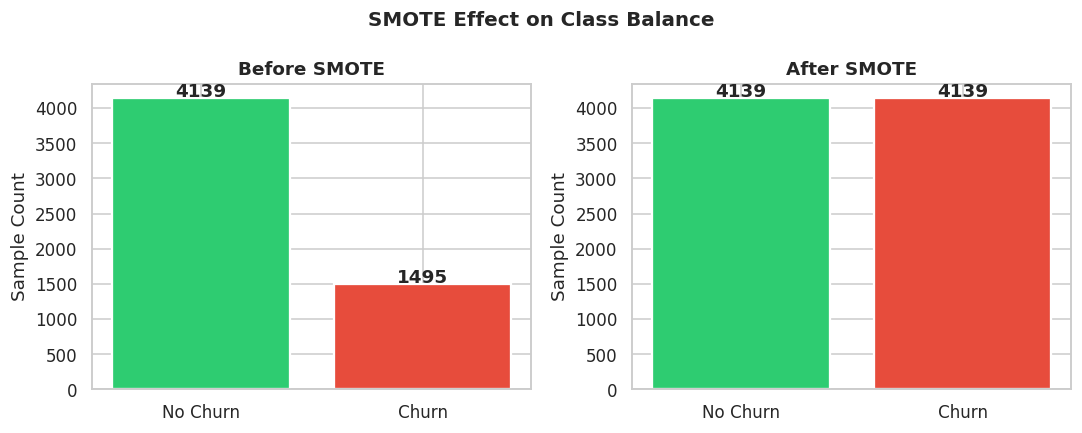

In [15]:
# ── Visual: Before vs After SMOTE ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, counts, title in [
    (axes[0], y_train.value_counts(), 'Before SMOTE'),
    (axes[1], pd.Series(y_train_sm).value_counts(), 'After SMOTE')
]:
    ax.bar(['No Churn','Churn'], [counts[0], counts[1]],
           color=['#2ecc71','#e74c3c'], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Sample Count')
    for i, v in enumerate([counts[0], counts[1]]):
        ax.text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE Effect on Class Balance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Step 7 — Train Models (Both Strategies)

In [16]:
# ── Define models under BOTH strategies ──

# Strategy A: SMOTE (balanced training data, no class_weight)
models_smote = {
    'LR (SMOTE)'  : LogisticRegression(max_iter=1000, random_state=42),
    'RF (SMOTE)'  : RandomForestClassifier(n_estimators=200, max_depth=10,
                                            random_state=42, n_jobs=-1),
    'XGB (SMOTE)' : XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                                   use_label_encoder=False, eval_metric='logloss',
                                   random_state=42, verbosity=0),
    'LGBM (SMOTE)': LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                                    random_state=42, verbose=-1)
}

# Strategy B: Class Weights (original imbalanced data, model handles internally)
models_cw = {
    'LR (CW)'  : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'RF (CW)'  : RandomForestClassifier(class_weight='balanced', n_estimators=200,
                                         max_depth=10, random_state=42, n_jobs=-1),
    'XGB (CW)' : XGBClassifier(scale_pos_weight=n_neg/n_pos,  # XGB equivalent of class_weight
                                n_estimators=200, learning_rate=0.05, max_depth=5,
                                use_label_encoder=False, eval_metric='logloss',
                                random_state=42, verbosity=0),
    'LGBM (CW)': LGBMClassifier(class_weight='balanced', n_estimators=200,
                                  learning_rate=0.05, max_depth=5,
                                  random_state=42, verbose=-1)
}

print('Models defined ✅')
print('Strategy A (SMOTE): trained on resampled balanced data')
print('Strategy B (Class Weights): trained on original data with weighted loss')

Models defined ✅
Strategy A (SMOTE): trained on resampled balanced data
Strategy B (Class Weights): trained on original data with weighted loss


In [17]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train model and return metrics dict + predictions."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    return {
        'Accuracy' : round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_te, y_pred), 4),
        'F1'       : round(f1_score(y_te, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_te, y_proba), 4)
    }, y_pred, y_proba


results = {}
all_preds = {}

print('Training SMOTE models...')
for name, model in models_smote.items():
    metrics, y_pred, y_proba = evaluate_model(
        name, model, X_train_sm, y_train_sm, X_test_sc, y_test
    )
    results[name] = metrics
    all_preds[name] = (model, y_pred, y_proba)
    print(f'  {name:<16} Recall={metrics["Recall"]:.4f}  F1={metrics["F1"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')

print('\nTraining Class-Weight models...')
for name, model in models_cw.items():
    metrics, y_pred, y_proba = evaluate_model(
        name, model, X_train_sc, y_train, X_test_sc, y_test
    )
    results[name] = metrics
    all_preds[name] = (model, y_pred, y_proba)
    print(f'  {name:<16} Recall={metrics["Recall"]:.4f}  F1={metrics["F1"]:.4f}  AUC={metrics["ROC-AUC"]:.4f}')

print('\n✅ All models trained!')

Training SMOTE models...
  LR (SMOTE)       Recall=0.7834  F1=0.6136  AUC=0.8466
  RF (SMOTE)       Recall=0.7193  F1=0.6198  AUC=0.8418
  XGB (SMOTE)      Recall=0.6364  F1=0.5980  AUC=0.8380
  LGBM (SMOTE)     Recall=0.6230  F1=0.5944  AUC=0.8374

Training Class-Weight models...
  LR (CW)          Recall=0.7834  F1=0.6168  AUC=0.8468
  RF (CW)          Recall=0.7299  F1=0.6290  AUC=0.8402
  XGB (CW)         Recall=0.7834  F1=0.6335  AUC=0.8417
  LGBM (CW)        Recall=0.7807  F1=0.6253  AUC=0.8387

✅ All models trained!


## 📊 Step 8 — Model Comparison & Leaderboard

In [18]:
results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)

print('='*72)
print('           MODEL LEADERBOARD (sorted by ROC-AUC)')
print('='*72)
print(f'{"Model":<18} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"ROC-AUC":>9}')
print('-'*72)
for i, (name, row) in enumerate(results_df.iterrows()):
    medal = ['🥇','🥈','🥉','   ','   ','   ','   ','   '][i]
    print(f'{medal} {name:<16} {row["Accuracy"]:>9} {row["Precision"]:>10} '
          f'{row["Recall"]:>8} {row["F1"]:>8} {row["ROC-AUC"]:>9}')
print('='*72)

best_name = results_df.index[0]
print(f'\n🏆 BEST MODEL: {best_name}')

           MODEL LEADERBOARD (sorted by ROC-AUC)
Model               Accuracy  Precision   Recall       F1   ROC-AUC
------------------------------------------------------------------------
🥇 LR (CW)             0.7417     0.5087   0.7834   0.6168    0.8468
🥈 LR (SMOTE)          0.7381     0.5043   0.7834   0.6136    0.8466
🥉 RF (SMOTE)          0.7658     0.5445   0.7193   0.6198    0.8418
    XGB (CW)            0.7594     0.5318   0.7834   0.6335    0.8417
    RF (CW)             0.7715     0.5526   0.7299    0.629    0.8402
    LGBM (CW)           0.7516     0.5214   0.7807   0.6253    0.8387
    XGB (SMOTE)         0.7729      0.564   0.6364    0.598     0.838
    LGBM (SMOTE)        0.7743     0.5683    0.623   0.5944    0.8374

🏆 BEST MODEL: LR (CW)


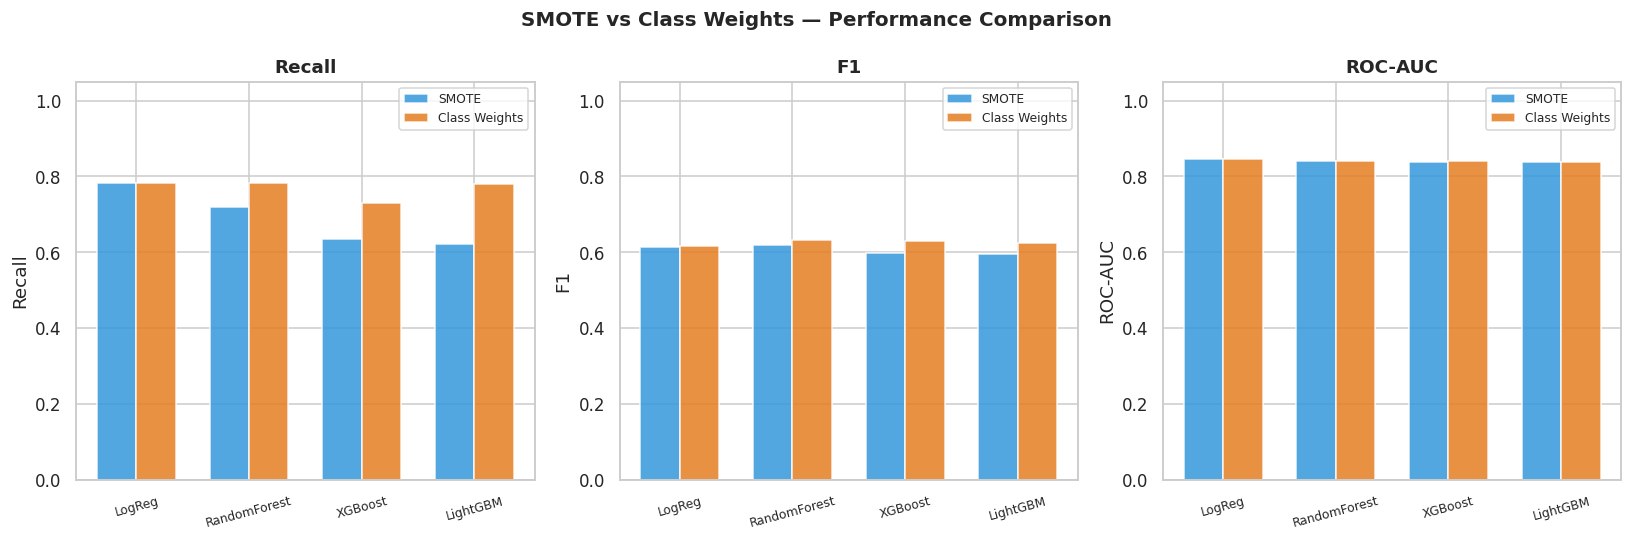

In [19]:
# ── Grouped bar chart: SMOTE vs Class Weights across metrics ──
metrics_plot = ['Recall', 'F1', 'ROC-AUC']
smote_names = [n for n in results_df.index if 'SMOTE' in n]
cw_names    = [n for n in results_df.index if 'CW' in n]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = np.arange(4)  # 4 model types
model_labels = ['LogReg','RandomForest','XGBoost','LightGBM']
width = 0.35

for ax, metric in zip(axes, metrics_plot):
    smote_vals = [results[n][metric] for n in smote_names]
    cw_vals    = [results[n][metric] for n in cw_names]
    ax.bar(x - width/2, smote_vals, width, label='SMOTE', color='#3498db', alpha=0.85)
    ax.bar(x + width/2, cw_vals,    width, label='Class Weights', color='#e67e22', alpha=0.85)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=15, fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.set_ylabel(metric)

plt.suptitle('SMOTE vs Class Weights — Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔲 Step 9 — Confusion Matrices & ROC Curves

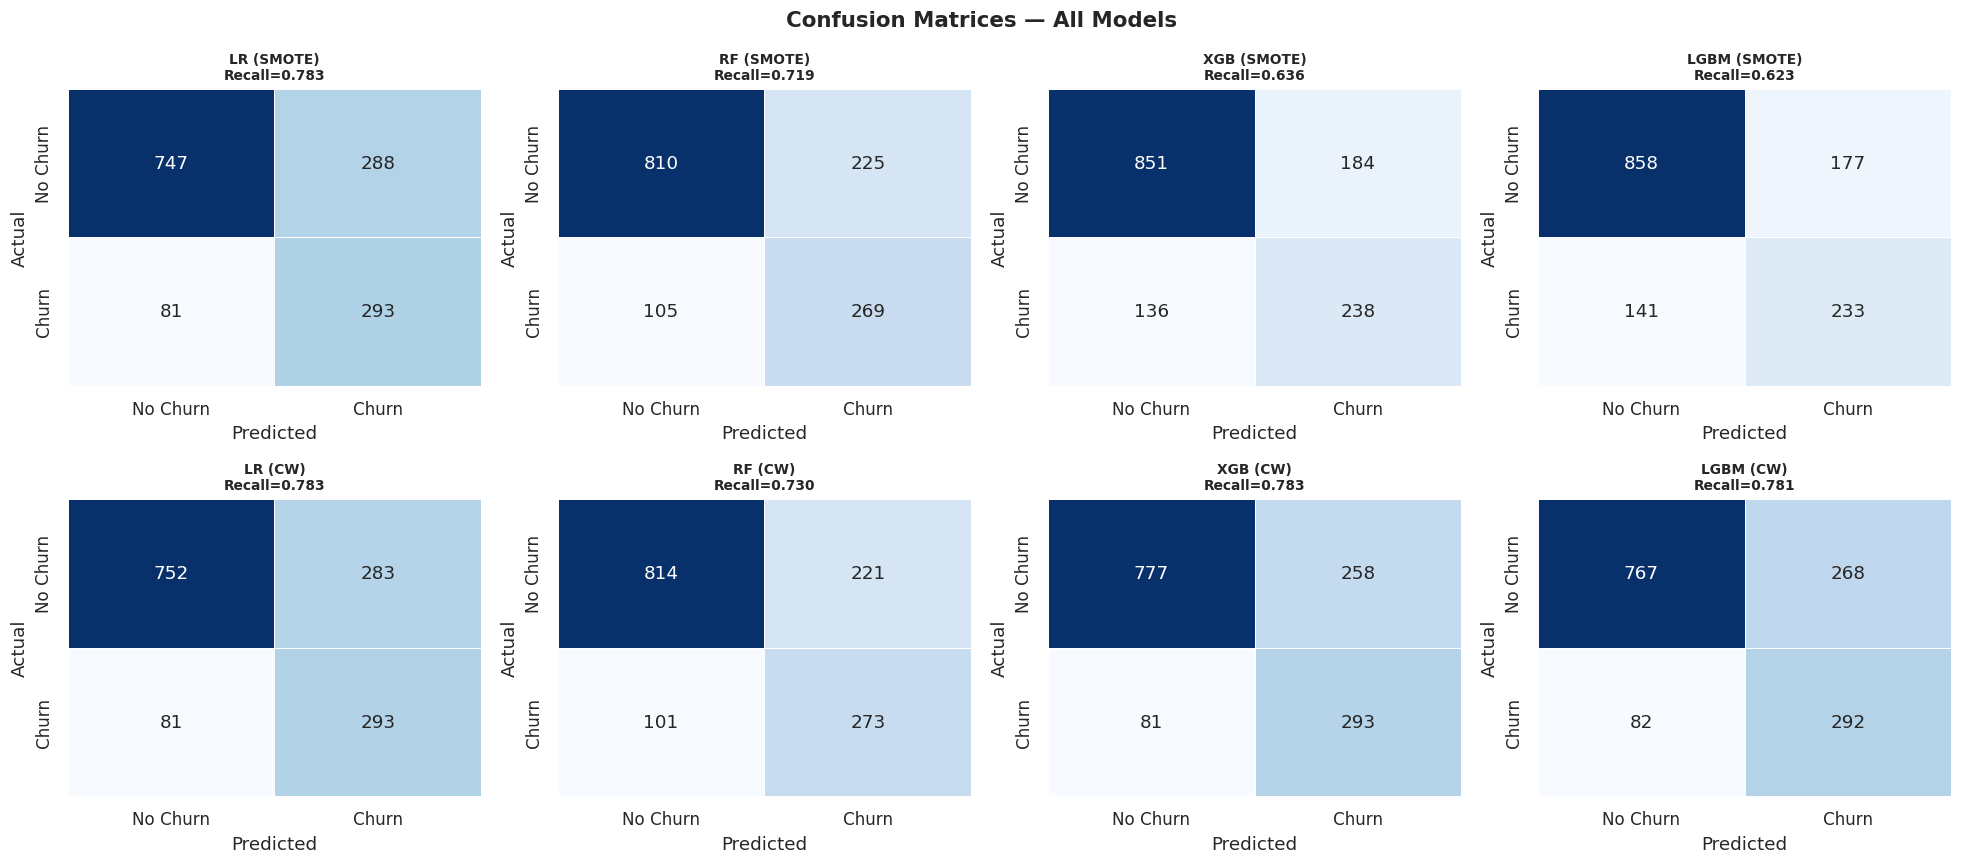

Key: High Recall = fewer missed churners (False Negatives) → most important for business!


In [20]:
# ── Confusion matrix for all 8 models ──
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (name, (model, y_pred, y_proba)) in enumerate(all_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'],
                linewidths=0.5, cbar=False)
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(f'{name}\nRecall={results[name]["Recall"]:.3f}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Key: High Recall = fewer missed churners (False Negatives) → most important for business!')

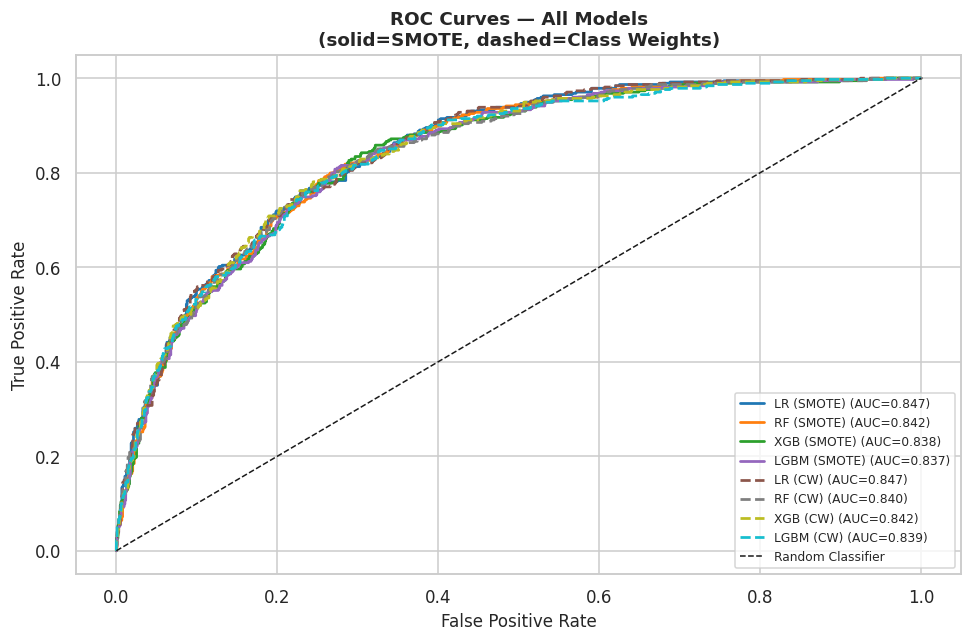

In [22]:
# ── ROC Curves — all 8 models on one plot ──
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 8))

for (name, (model, y_pred, y_proba)), color in zip(all_preds.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = results[name]['ROC-AUC']
    linestyle = '-' if 'SMOTE' in name else '--'
    ax.plot(fpr, tpr, color=color, lw=1.8, linestyle=linestyle,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models\n(solid=SMOTE, dashed=Class Weights)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

## 🌟 Step 10 — Feature Importance (Best Model)

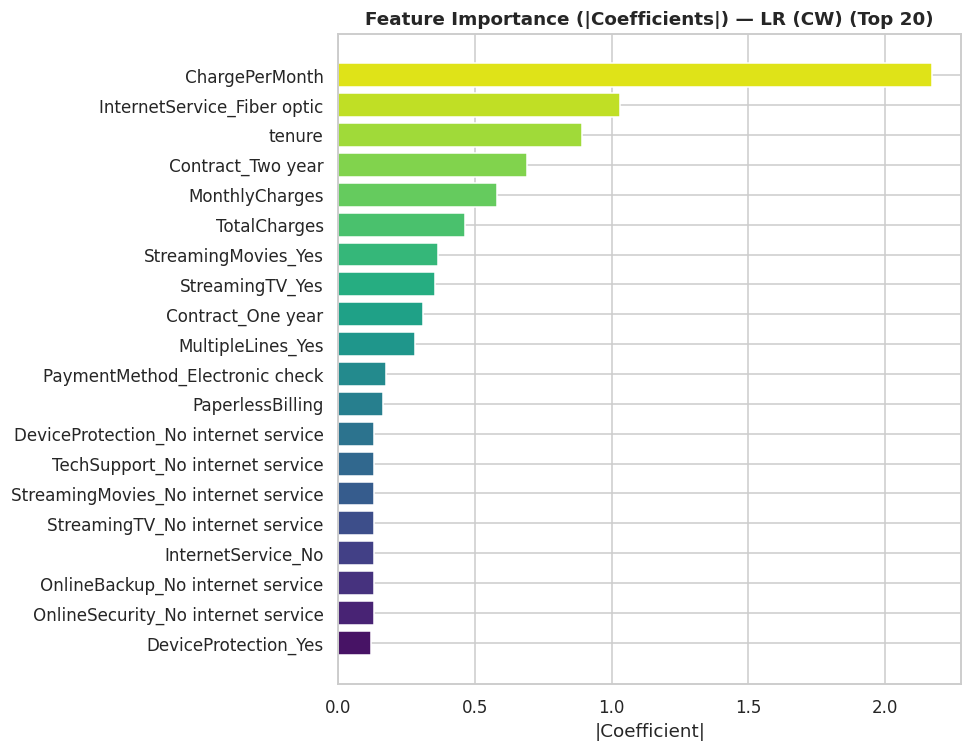

In [23]:
best_model_obj = all_preds[best_name][0]

# Check if model has built-in feature importance
if hasattr(best_model_obj, 'feature_importances_'):
    fi = best_model_obj.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': fi})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(20)  # top 20

    plt.figure(figsize=(9, 7))
    plt.barh(fi_df['Feature'], fi_df['Importance'],
             color=sns.color_palette('viridis', len(fi_df)))
    plt.title(f'Feature Importance — {best_name} (Top 20)', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    # Logistic Regression: use coefficient magnitudes
    coef = np.abs(best_model_obj.coef_[0])
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': coef})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(20)

    plt.figure(figsize=(9, 7))
    plt.barh(fi_df['Feature'], fi_df['Importance'],
             color=sns.color_palette('viridis', len(fi_df)))
    plt.title(f'Feature Importance (|Coefficients|) — {best_name} (Top 20)',
              fontsize=12, fontweight='bold')
    plt.xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()

## 🔬 Step 11 — SHAP Explainability (Best Model)

In [28]:
# ── SHAP: assigns each feature a contribution value per prediction ──
print(f'Computing SHAP values for: {best_name}...\n')

X_test_df = pd.DataFrame(X_test_sc, columns=feature_names)
X_train_df = pd.DataFrame(
    X_train_sm if 'SMOTE' in best_name else X_train_sc,
    columns=feature_names
)

if any(m in best_name for m in ['RF','XGB','LGBM']):
    explainer   = shap.TreeExplainer(best_model_obj)
    shap_values = explainer.shap_values(X_test_df)
    # For RF: shap_values is list [class0, class1] — take class 1 (Churn)
    if isinstance(shap_values, list):
        shap_vals_churn = shap_values[1]
    else:
        shap_vals_churn = shap_values
    expected_val = (explainer.expected_value[1]
                    if isinstance(explainer.expected_value, (list, np.ndarray))
                    else explainer.expected_value)
else:
    background = shap.sample(X_train_df, 100, random_state=42)
    explainer   = shap.KernelExplainer(best_model_obj.predict_proba, background)
    shap_values = explainer.shap_values(X_test_df.iloc[:300])
    # Correctly extract SHAP values for class 1 (Churn) across all samples and features
    shap_vals_churn = shap_values[:, :, 1] # SHAP values for class 1
    expected_val    = explainer.expected_value[1]

print('SHAP values computed ✅')

Computing SHAP values for: LR (CW)...



  0%|          | 0/300 [00:00<?, ?it/s]

SHAP values computed ✅


Shape of shap_vals_churn: (300, 32)
Shape of X_test_df.iloc[:300].values: (300, 32)


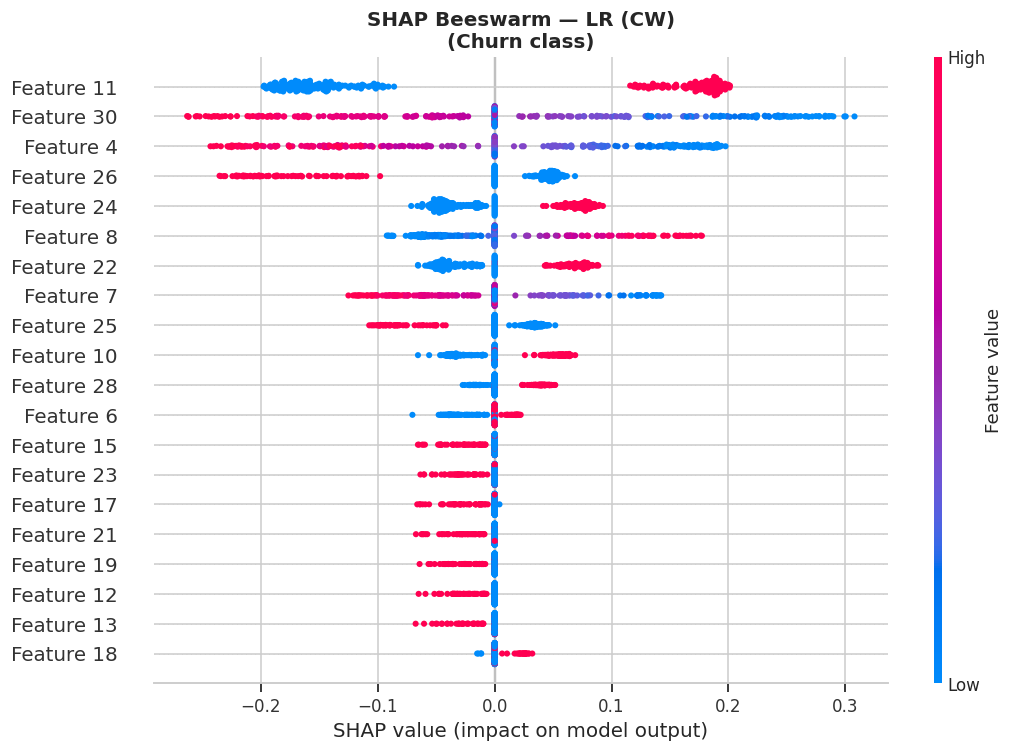

In [37]:
# ── SHAP Beeswarm Summary ──
# Each dot = one test sample
# x-axis = SHAP value (positive → pushes toward Churn)
# colour  = actual feature value (red=high, blue=low)
plt.figure()

# Debugging: Print shapes before plotting
print(f"Shape of shap_vals_churn: {shap_vals_churn.shape}")
print(f"Shape of X_test_df.iloc[:300].values: {X_test_df.iloc[:300].values.shape}")

shap.summary_plot(shap_vals_churn, X_test_df.iloc[:300].values, show=False, plot_size=(10, 7), max_display=20)
plt.title(f'SHAP Beeswarm — {best_name}\n(Churn class)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

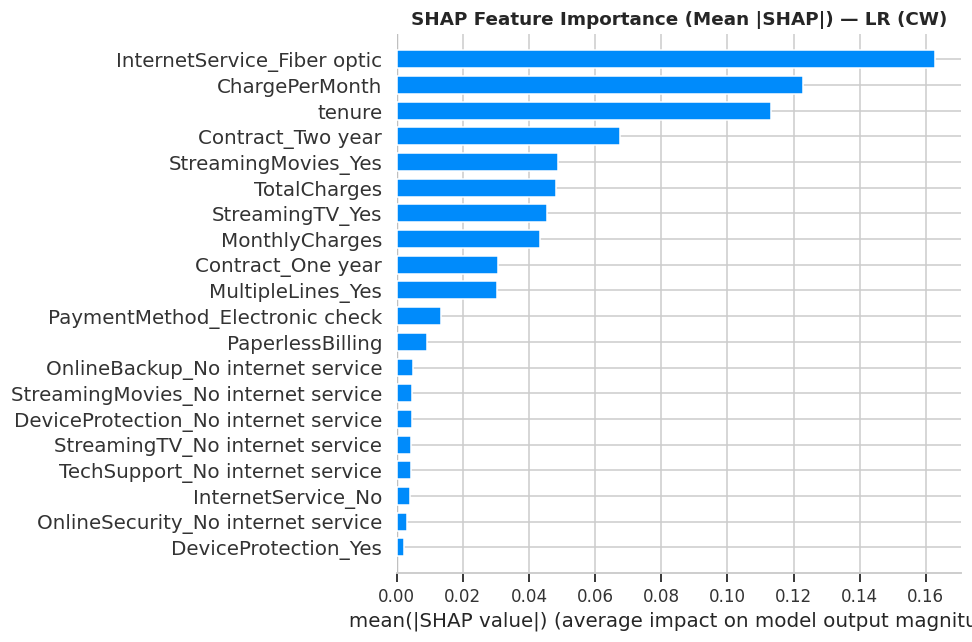

In [38]:
# ── SHAP Bar — Mean |SHAP| per feature ──
plt.figure()
shap.summary_plot(shap_vals_churn, X_test_df, plot_type='bar',
                  show=False, plot_size=(9, 6), max_display=20)
plt.title(f'SHAP Feature Importance (Mean |SHAP|) — {best_name}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

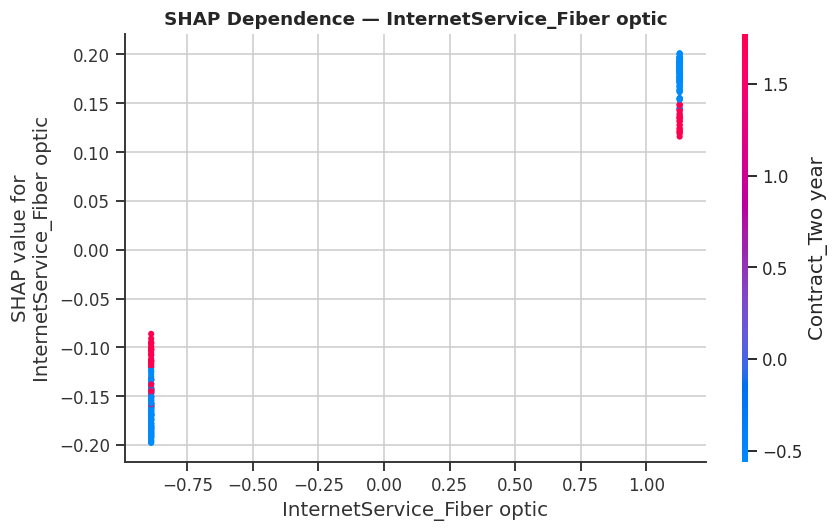

In [39]:
# ── SHAP Dependence — top SHAP feature ──
top_shap_feat = X_test_df.columns[
    np.argmax(np.abs(shap_vals_churn).mean(axis=0))
]
plt.figure(figsize=(8, 5))
shap.dependence_plot(top_shap_feat, shap_vals_churn, X_test_df.iloc[:300], # Pass the sliced X_test_df
                     show=False, ax=plt.gca())
plt.title(f'SHAP Dependence — {top_shap_feat}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Sample #0  →  Actual: No Churn  | Predicted: No Churn


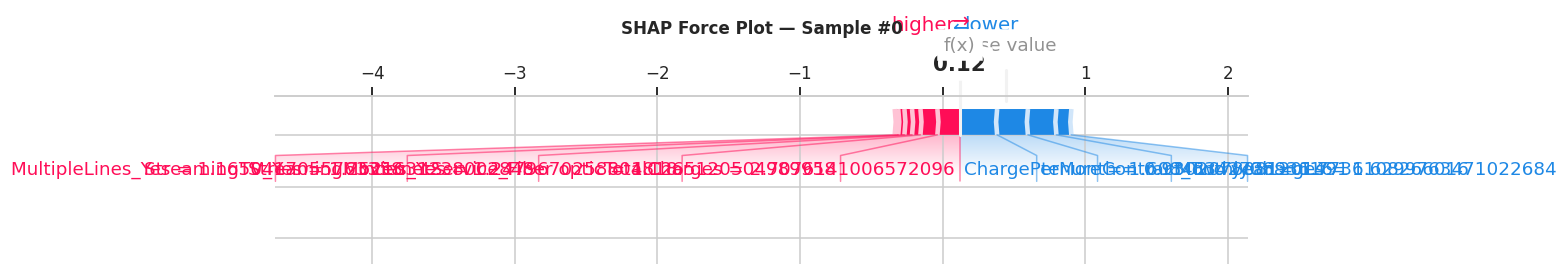

In [40]:
# ── SHAP Force Plot — explain a single prediction ──
# Red features push prediction toward CHURN; blue push toward NO CHURN
shap.initjs()
idx = 0  # change to explain a different test sample

actual    = y_test.values[idx]
predicted = all_preds[best_name][1][idx]
print(f'Sample #{idx}  →  Actual: {"Churn" if actual==1 else "No Churn"}  '
      f'| Predicted: {"Churn" if predicted==1 else "No Churn"}')

shap.force_plot(
    expected_val,
    shap_vals_churn[idx],
    X_test_df.iloc[idx],
    matplotlib=True,
    show=False,
    figsize=(14, 3)
)
plt.title(f'SHAP Force Plot — Sample #{idx}', fontsize=11, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 📋 Step 12 — Classification Report (Best Model)

In [41]:
best_preds = all_preds[best_name][1]
print(f'Classification Report — {best_name}')
print('='*50)
print(classification_report(y_test, best_preds,
                             target_names=['No Churn','Churn']))

print('\nMetric Glossary:')
print('  Precision : of all predicted churners, how many actually churned')
print('  Recall    : of all actual churners, how many did we catch   ← most business-critical')
print('  F1        : harmonic mean of Precision & Recall')
print('  ROC-AUC   : model ability to rank churners above non-churners')

Classification Report — LR (CW)
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Metric Glossary:
  Precision : of all predicted churners, how many actually churned
  Recall    : of all actual churners, how many did we catch   ← most business-critical
  F1        : harmonic mean of Precision & Recall
  ROC-AUC   : model ability to rank churners above non-churners


## 🏁 Step 13 — Final Summary

In [42]:
print('='*72)
print('              CUSTOMER CHURN PREDICTION — FINAL SUMMARY')
print('='*72)
print(f'\n📌 Dataset       : IBM Telco Customer Churn (7,043 customers)')
print(f'📌 Class Ratio   : ~74% No-Churn vs ~26% Churn (imbalanced)')
print(f'📌 Models Trained: 8 (4 models × 2 imbalance strategies)')
print(f'\n🏆 Best Model    : {best_name}')
print(f'   Recall        : {results_df.loc[best_name, "Recall"]}   ← captures most actual churners')
print(f'   F1 Score      : {results_df.loc[best_name, "F1"]}')
print(f'   ROC-AUC       : {results_df.loc[best_name, "ROC-AUC"]}')

# SMOTE vs CW average comparison
smote_avg_auc = np.mean([results[n]['ROC-AUC'] for n in smote_names])
cw_avg_auc    = np.mean([results[n]['ROC-AUC'] for n in cw_names])
smote_avg_rec = np.mean([results[n]['Recall'] for n in smote_names])
cw_avg_rec    = np.mean([results[n]['Recall'] for n in cw_names])

print(f'\n⚖️  SMOTE vs Class Weights (averaged across 4 models):')
print(f'   SMOTE       → Avg AUC={smote_avg_auc:.4f}  Avg Recall={smote_avg_rec:.4f}')
print(f'   Class Wts   → Avg AUC={cw_avg_auc:.4f}  Avg Recall={cw_avg_rec:.4f}')
winner = 'SMOTE' if smote_avg_rec >= cw_avg_rec else 'Class Weights'
print(f'   → {winner} gives better recall on this dataset')

print(f'\n🔍 KEY SHAP FINDINGS:')
print('   • tenure         — longer tenure → much less likely to churn')
print('   • Contract type  — month-to-month contracts churn most')
print('   • MonthlyCharges — higher charges → higher churn risk')
print('   • TechSupport    — no tech support → higher churn')
print('   • OnlineSecurity — no security service → higher churn')
print('='*72)

              CUSTOMER CHURN PREDICTION — FINAL SUMMARY

📌 Dataset       : IBM Telco Customer Churn (7,043 customers)
📌 Class Ratio   : ~74% No-Churn vs ~26% Churn (imbalanced)
📌 Models Trained: 8 (4 models × 2 imbalance strategies)

🏆 Best Model    : LR (CW)
   Recall        : 0.7834   ← captures most actual churners
   F1 Score      : 0.6168
   ROC-AUC       : 0.8468

⚖️  SMOTE vs Class Weights (averaged across 4 models):
   SMOTE       → Avg AUC=0.8410  Avg Recall=0.6905
   Class Wts   → Avg AUC=0.8418  Avg Recall=0.7693
   → Class Weights gives better recall on this dataset

🔍 KEY SHAP FINDINGS:
   • tenure         — longer tenure → much less likely to churn
   • Contract type  — month-to-month contracts churn most
   • MonthlyCharges — higher charges → higher churn risk
   • TechSupport    — no tech support → higher churn
   • OnlineSecurity — no security service → higher churn
